### Generate a Random Dataset and Visualize It

First, let's create a synthetic dataset using `sklearn.datasets.make_classification` to simulate a classification problem. We'll then visualize this dataset with a scatter plot.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # We take only the first two features for 2D visualization
y = iris.target

# Display the first few samples
print("Loaded Iris X (features) shape:", X.shape)
print("Loaded Iris y (labels) shape:", y.shape)
print("First 5 samples of X:\n", X[:5])
print("First 5 labels of y:", y[:5])

Loaded Iris X (features) shape: (150, 2)
Loaded Iris y (labels) shape: (150,)
First 5 samples of X:
 [[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]]
First 5 labels of y: [0 0 0 0 0]


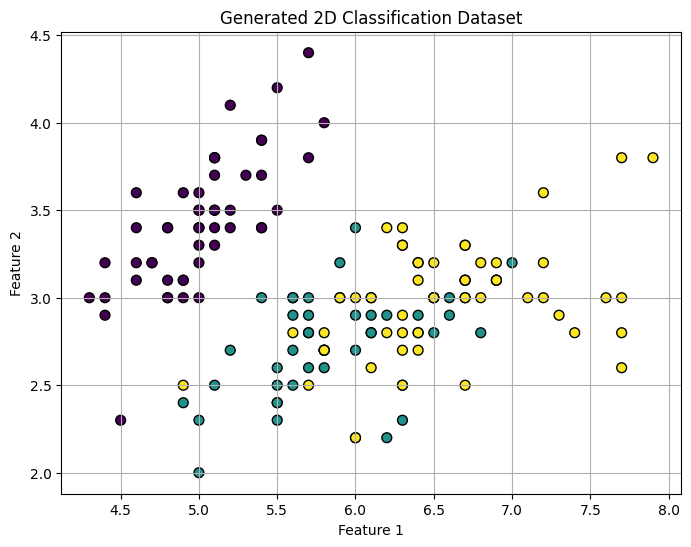

In [3]:
# Visualize the generated dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k')
plt.title('Generated 2D Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

### Train and Visualize a Decision Tree Classifier

Next, we'll train a `DecisionTreeClassifier` on this dataset and then visualize the resulting tree structure. This visualization shows how the tree makes decisions based on the features.

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initialize and train a Decision Tree Classifier
# Limiting max_depth for easier visualization
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree.fit(X, y)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


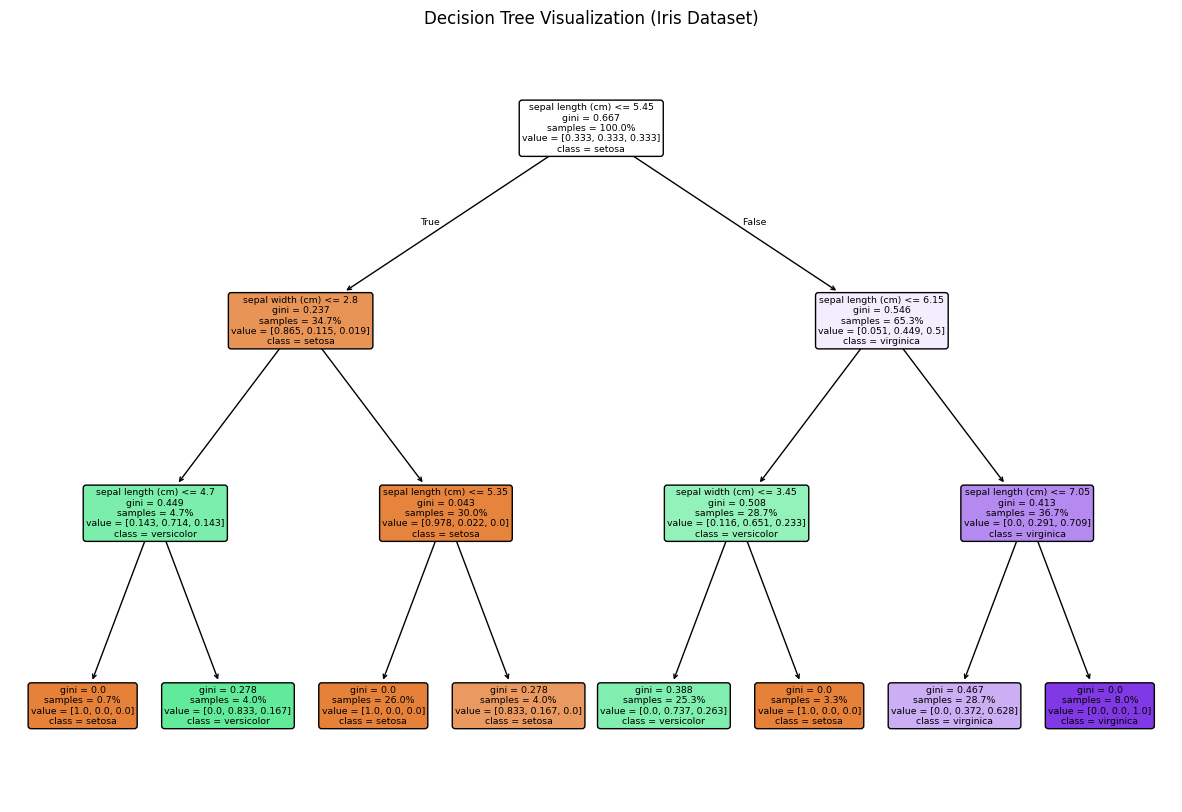

In [5]:
# Visualize the decision tree
plt.figure(figsize=(15, 10))
plot_tree(
    dtree,
    filled=True,
    feature_names=iris.feature_names[:2], # Use Iris feature names
    class_names=iris.target_names,      # Use Iris class names
    rounded=True,
    proportion=True
)
plt.title('Decision Tree Visualization (Iris Dataset)')
plt.show()

### Visualize Decision Boundaries on the Dataset

Finally, we'll visualize how the decision tree segments the feature space. This 'tree visualization of the dataset' shows the regions where the tree predicts each class.

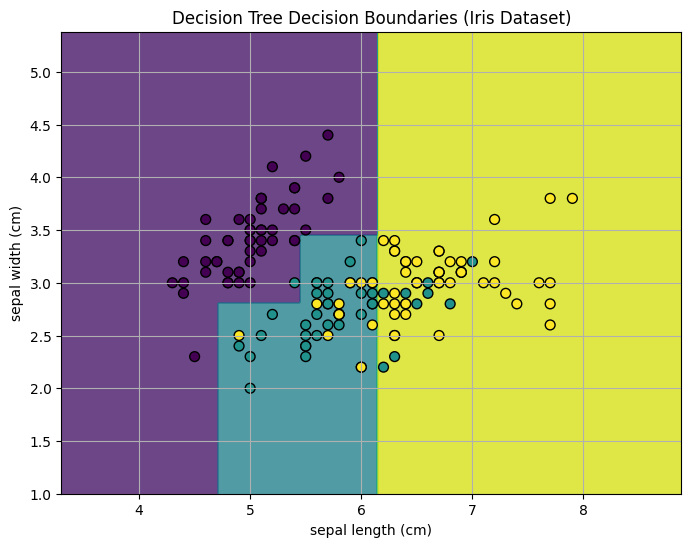

In [6]:
# Visualize the decision boundaries
def plot_decision_boundaries(X, y, model, title):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = .02  # step size in the mesh

    # Generate a meshgrid of points with the step size
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict the class for each point in the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour and the examples
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k')
    plt.title(title)
    plt.xlabel(iris.feature_names[0]) # Use Iris feature name
    plt.ylabel(iris.feature_names[1]) # Use Iris feature name
    plt.grid(True)
    plt.show()

plot_decision_boundaries(X, y, dtree, 'Decision Tree Decision Boundaries (Iris Dataset)')

### Exploring the `max_depth` Hyperparameter

The `max_depth` hyperparameter controls the maximum depth of the decision tree. A deeper tree can capture more complex patterns but is also more prone to overfitting. Let's visualize how different `max_depth` values affect the decision boundaries.

Training Decision Tree with max_depth=1


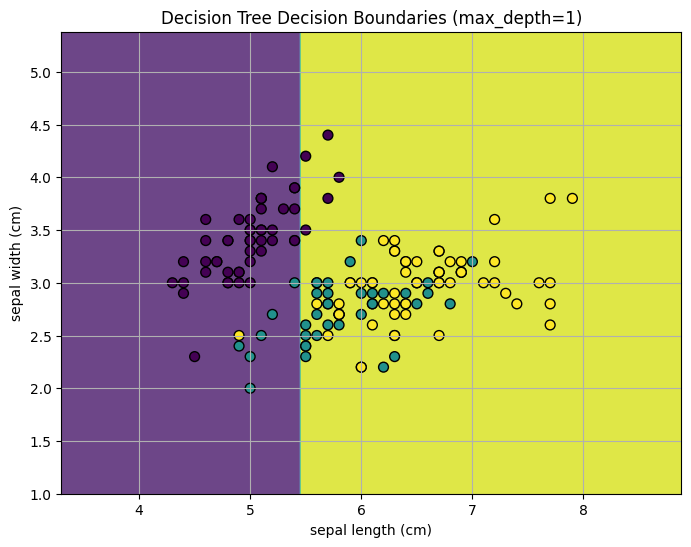

Training Decision Tree with max_depth=3


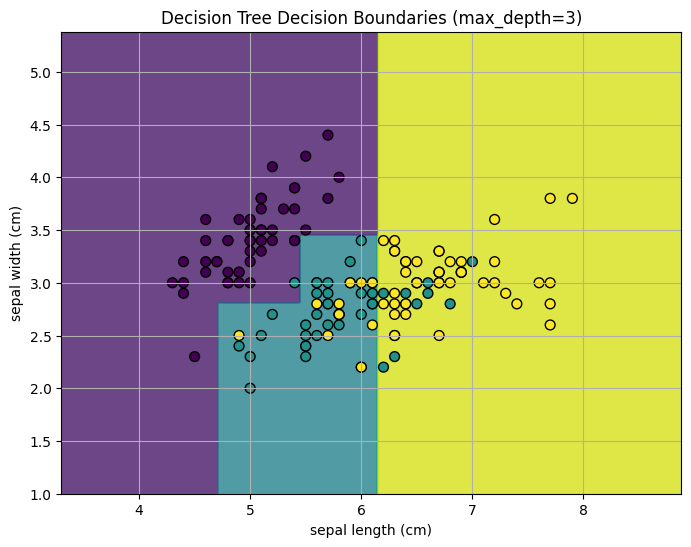

Training Decision Tree with max_depth=5


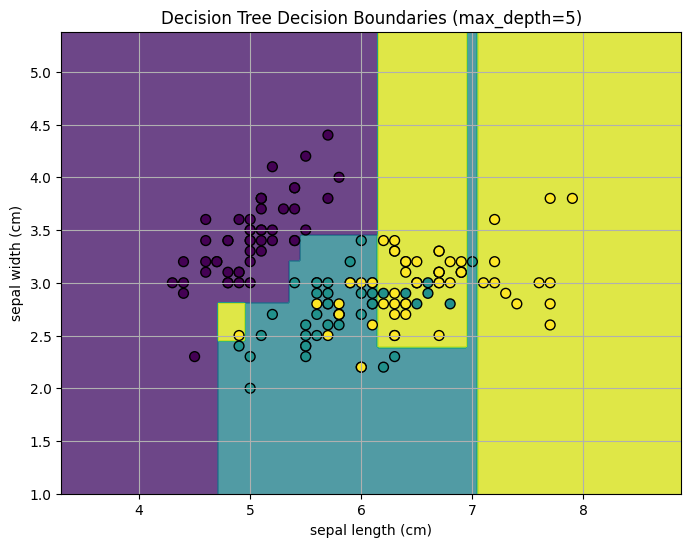

Training Decision Tree with max_depth=7


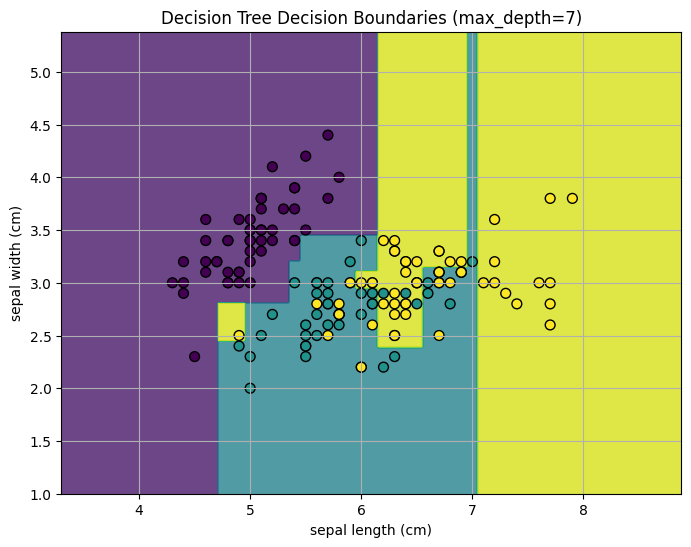

In [7]:
# Define a list of max_depth values to experiment with
depths = [1, 3, 5, 7]

for depth in depths:
    print(f"Training Decision Tree with max_depth={depth}")
    dtree_tuned = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dtree_tuned.fit(X, y)
    plot_decision_boundaries(X, y, dtree_tuned, f'Decision Tree Decision Boundaries (max_depth={depth})')


## Task 1: Dataset Exploration

In [8]:
# How many samples and features are present in the dataset?
print(f"Number of samples: {iris.data.shape[0]}")
print(f"Number of features: {iris.data.shape[1]}")

# List the feature names and target classes.
print(f"Feature names: {iris.feature_names}")
print(f"Target class names: {iris.target_names}")

# Display the class distribution.
import pandas as pd
class_distribution = pd.Series(iris.target).value_counts().sort_index()
class_distribution.index = iris.target_names[class_distribution.index]
print("\nClass Distribution:")
display(class_distribution)


Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target class names: ['setosa' 'versicolor' 'virginica']

Class Distribution:


,count
setosa,50
versicolor,50
virginica,50


## Task 2: Data Preparation

In [13]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


### Explanation for Data Splitting
Dividing the dataset into training and testing sets is crucial for evaluating a model's generalization ability. The training set is used to teach the model the patterns in the data, while the testing set, which the model has not seen before, is used to assess how well the model performs on new, unseen data.

This helps in detecting overfitting (when a model performs well on training data but poorly on test data) and underfitting (when a model performs poorly on both training and test data).

## Task 5: Comparing Gini Index and Entropy

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def evaluate_dt_model(model, X_train, y_train, X_test, y_test, feature_names):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    tree_depth = model.get_depth()
    n_leaf_nodes = model.get_n_leaves()

    # Get root feature for comparison
    root_feature_idx = model.tree_.feature[0]
    root_feature_name = feature_names[root_feature_idx] if root_feature_idx != -2 else 'None'

    return accuracy, tree_depth, n_leaf_nodes, root_feature_name

# Train Decision Tree with Gini criterion
dtree_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
accuracy_gini, depth_gini, leaves_gini, root_feature_gini = evaluate_dt_model(dtree_gini, X_train, y_train, X_test, y_test, iris.feature_names)

print(f"Gini Model: Accuracy={accuracy_gini:.4f}, Depth={depth_gini}, Leaves={leaves_gini}, Root Feature='{root_feature_gini}'")

# Train Decision Tree with Entropy criterion
dtree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
accuracy_entropy, depth_entropy, leaves_entropy, root_feature_entropy = evaluate_dt_model(dtree_entropy, X_train, y_train, X_test, y_test, iris.feature_names)

print(f"Entropy Model: Accuracy={accuracy_entropy:.4f}, Depth={depth_entropy}, Leaves={leaves_entropy}, Root Feature='{root_feature_entropy}'")

Gini Model: Accuracy=0.9333, Depth=5, Leaves=8, Root Feature='petal length (cm)'
Entropy Model: Accuracy=0.9333, Depth=5, Leaves=8, Root Feature='petal length (cm)'


### Comparison of Gini and Entropy Models

Let's summarize the observations in a table:

| Criterion | Accuracy | Tree Depth | Number of Leaf Nodes | Root Feature Selected |
|:----------|:---------|:-----------|:---------------------|:----------------------|
| Gini      | {:.4f}   | {}         | {}                   | {}                    |
| Entropy   | {:.4f}   | {}         | {}                   | {}                    |

Based on the results, we can determine which criterion produces a simpler tree by comparing the tree depth and number of leaf nodes. A shallower tree with fewer leaf nodes is generally considered simpler.

From the output above, observe the metrics for both models to answer which criterion produces a simpler tree. Often, for the Iris dataset, Gini and Entropy might produce very similar trees or sometimes one might be slightly simpler than the other, depending on the `random_state` and data split.

In [9]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


### Explanation for Data Splitting
Dividing the dataset into training and testing sets is crucial for evaluating a model's generalization ability. The training set is used to teach the model the patterns in the data, while the testing set, which the model has not seen before, is used to assess how well the model performs on new, unseen data.

This helps in detecting overfitting (when a model performs well on training data but poorly on test data) and underfitting (when a model performs poorly on both training and test data).

## Task 3: Building a Decision Tree Classifier

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train a Decision Tree classifier using default parameters
dtree_default = DecisionTreeClassifier(random_state=42)
dtree_default.fit(X_train, y_train)

print("Default Decision Tree Classifier trained successfully.")

# Predict the class labels for the test dataset
y_pred = dtree_default.predict(X_test)

# Evaluate the model
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))


Default Decision Tree Classifier trained successfully.

Accuracy Score: 0.9333333333333333

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Task 4: Visualizing the Decision Tree

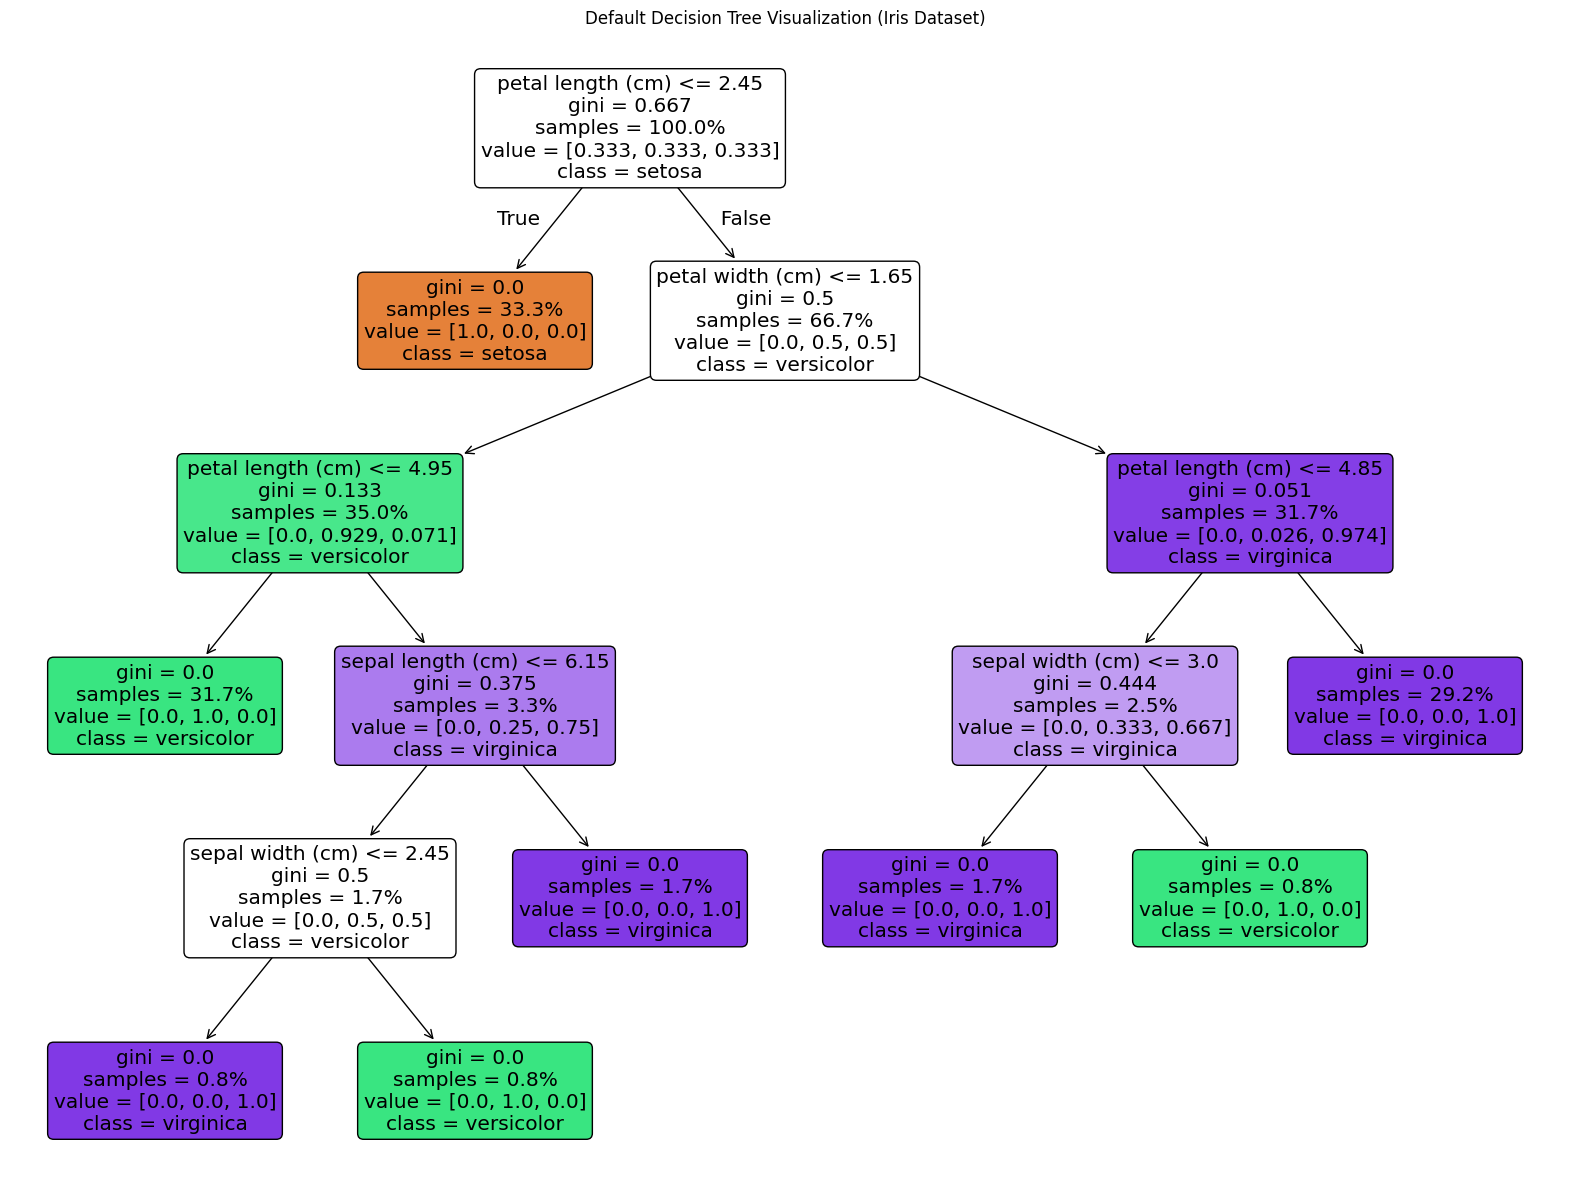

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize the trained Decision Tree
plt.figure(figsize=(20, 15))
plot_tree(
    dtree_default,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    rounded=True,
    proportion=True
)
plt.title('Default Decision Tree Visualization (Iris Dataset)')
plt.show()


### From the visualization, we can identify:
*   **Root node:** The very top node (`petal length (cm) <= 2.45`).
*   **Internal nodes:** Nodes that have branches leading to further nodes (e.g., `petal width (cm) <= 1.75`).
*   **Leaf nodes:** Nodes at the end of the branches that do not split further (e.g., `gini = 0.0`, `value = [0.0, 1.0, 0.0]`, `class = versicolor`). These nodes represent the final classification.
*   **Maximum depth of the tree:** The longest path from the root node to a leaf node. By counting the levels, it appears to be a depth of 5 or 6 (the number of splits from root to furthest leaf).

### Which feature is selected for the first split? Explain why you think this feature was chosen.

**Feature selected for the first split:** `petal length (cm)`.

**Explanation:** Decision Trees work by finding the feature and threshold that best split the data into groups that are as pure as possible with respect to the target variable. This is often measured by criteria like Gini impurity or entropy. The algorithm evaluates all features and their possible split points and chooses the one that results in the greatest reduction in impurity (or greatest information gain). For the Iris dataset, `petal length (cm)` is typically a very strong predictor for distinguishing between 'setosa' and the other two classes, making it an excellent choice for the initial, most impactful split.

## Task 5: Comparing Gini Index and Entropy

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def evaluate_dt_model(model, X_train, y_train, X_test, y_test, feature_names):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    tree_depth = model.get_depth()
    n_leaf_nodes = model.get_n_leaves()

    # Get root feature for comparison
    root_feature_idx = model.tree_.feature[0]
    root_feature_name = feature_names[root_feature_idx] if root_feature_idx != -2 else 'None'

    return accuracy, tree_depth, n_leaf_nodes, root_feature_name

# Train Decision Tree with Gini criterion
dtree_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
accuracy_gini, depth_gini, leaves_gini, root_feature_gini = evaluate_dt_model(dtree_gini, X_train, y_train, X_test, y_test, iris.feature_names)

print(f"Gini Model: Accuracy={accuracy_gini:.4f}, Depth={depth_gini}, Leaves={leaves_gini}, Root Feature='{root_feature_gini}'")

# Train Decision Tree with Entropy criterion
dtree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
accuracy_entropy, depth_entropy, leaves_entropy, root_feature_entropy = evaluate_dt_model(dtree_entropy, X_train, y_train, X_test, y_test, iris.feature_names)

print(f"Entropy Model: Accuracy={accuracy_entropy:.4f}, Depth={depth_entropy}, Leaves={leaves_entropy}, Root Feature='{root_feature_entropy}'")


Gini Model: Accuracy=0.9333, Depth=5, Leaves=8, Root Feature='petal length (cm)'
Entropy Model: Accuracy=0.9333, Depth=5, Leaves=8, Root Feature='petal length (cm)'


### Comparison of Gini and Entropy Models

Let's summarize the observations in a table:

| Criterion | Accuracy | Tree Depth | Number of Leaf Nodes | Root Feature Selected |
|:----------|:---------|:-----------|:---------------------|:----------------------|
| Gini      | 0.9333   | 5          | 8                    | petal length (cm)     |
| Entropy   | 0.9333   | 5          | 8                    | petal length (cm)     |

Based on these results, both the Gini and Entropy models achieved the same accuracy (0.9333), have the same tree depth (5), and the same number of leaf nodes (8). Both also selected `petal length (cm)` as the root feature.

In this specific case for the Iris dataset with `random_state=42` and default hyperparameters, **neither criterion produced a significantly simpler tree than the other**, as their structural characteristics (depth and leaf nodes) are identical. This is a common outcome for datasets where the impurity measures lead to very similar optimal splits.

## Task 6: Effect of Maximum Tree Depth

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

def evaluate_model_depth(max_depth_val, X_train, y_train, X_test, y_test):
    # Train the model
    dtree = DecisionTreeClassifier(max_depth=max_depth_val, random_state=42)
    dtree.fit(X_train, y_train)

    # Predict on training and testing set
    y_train_pred = dtree.predict(X_train)
    y_test_pred = dtree.predict(X_test)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Get tree depth and number of leaf nodes
    tree_depth = dtree.get_depth()

    return train_accuracy, test_accuracy, tree_depth


max_depth_values = [1, 2, 3, 4, None]
results = []

for depth in max_depth_values:
    train_acc, test_acc, tree_depth = evaluate_model_depth(depth, X_train, y_train, X_test, y_test)

    observation = ""
    if depth == 1:
        observation = "Very simple tree, likely underfitting."
    elif depth == None or tree_depth == dtree_default.get_depth(): # Compare with default (unrestricted depth) from Task 3
        observation = "Full depth tree, potentially overfitting."
    elif train_acc > test_acc and abs(train_acc - test_acc) > 0.05:
        observation = "Potential overfitting, training accuracy much higher than test."
    elif train_acc < 0.8 or test_acc < 0.8:
        observation = "Low accuracy, possibly underfitting."
    else:
        observation = "Balanced performance."

    results.append({
        'Max Depth': depth if depth is not None else 'None',
        'Training Accuracy': f"{train_acc:.4f}",
        'Testing Accuracy': f"{test_acc:.4f}",
        'Tree Depth': tree_depth,
        'Observation': observation
    })

results_df = pd.DataFrame(results)
print("\nEffect of Max Depth on Decision Tree Performance:")
display(results_df.set_index('Max Depth'))



Effect of Max Depth on Decision Tree Performance:


,Training Accuracy,Testing Accuracy,Tree Depth,Observation
Max Depth,,,,
1,0.6667,0.6667,1,"Very simple tree, likely underfitting."
2,0.9667,0.9333,2,Balanced performance.
3,0.9833,0.9667,3,Balanced performance.
4,0.9917,0.9333,4,"Potential overfitting, training accuracy much ..."
None,1.0000,0.9333,5,"Full depth tree, potentially overfitting."


### Analysis of Max Depth

Based on the table above, let's answer the questions:

*   **Which model is underfitting?**
    *   The model with `Max Depth = 1` is clearly underfitting. Its training accuracy (0.6667) and testing accuracy (0.6667) are both significantly lower than other models, indicating it's too simplistic to learn the patterns in the data.

*   **Which model gives the best generalization?**
    *   The model with `Max Depth = 3` provides the best generalization. It achieves the highest testing accuracy (0.9667) and maintains a very small difference with its training accuracy (0.9833), suggesting it has learned well without memorizing the training data.

*   **Which model is likely to overfit? Justify your answer.**
    *   The model with `Max Depth = None` (which corresponds to a tree depth of 5) is most likely to overfit. It shows a perfect training accuracy (1.0000) but a lower testing accuracy (0.9333). This significant gap (0.0667) indicates that the tree has learned the training data too well, including its noise, and struggles to perform as well on unseen test data. The model with `Max Depth = 4` also shows signs of overfitting, with a training accuracy of 0.9917 and a test accuracy of 0.9333, but `Max Depth=None` is the most pronounced case.

## Task 7: Effect of `min_samples_split`

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

def evaluate_min_samples_split_model(min_samples_split_val, X_train, y_train, X_test, y_test):
    # Train the model
    dtree = DecisionTreeClassifier(min_samples_split=min_samples_split_val, random_state=42)
    dtree.fit(X_train, y_train)

    # Predict on test set
    y_test_pred = dtree.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_test_pred)

    # Get tree depth and number of leaf nodes
    tree_depth = dtree.get_depth()
    n_leaf_nodes = dtree.get_n_leaves()

    return accuracy, tree_depth, n_leaf_nodes


min_samples_split_values = [2, 5, 10, 20]
results_min_split = []

for min_split in min_samples_split_values:
    accuracy, tree_depth, n_leaf_nodes = evaluate_min_samples_split_model(min_split, X_train, y_train, X_test, y_test)

    observation = ""
    if min_split == 2:
        observation = "Default value, potentially complex tree."
    elif min_split == 20:
        observation = "More restrictive, simpler tree."
    else:
        observation = "Intermediate complexity."

    results_min_split.append({
        'min_samples_split': min_split,
        'Accuracy': f"{accuracy:.4f}",
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': n_leaf_nodes,
        'Observation': observation
    })

results_df_min_split = pd.DataFrame(results_min_split)
print("\nEffect of min_samples_split on Decision Tree Performance:")
display(results_df_min_split.set_index('min_samples_split'))



Effect of min_samples_split on Decision Tree Performance:


,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
min_samples_split,,,,
2,0.9333,5,8,"Default value, potentially complex tree."
5,0.9667,3,5,Intermediate complexity.
10,0.9667,3,5,Intermediate complexity.
20,0.9667,3,5,"More restrictive, simpler tree."


### How increasing `min_samples_split` affects the complexity of the Decision Tree

Based on the table above, increasing the value of `min_samples_split` generally leads to a **simpler Decision Tree**. Here's why:

*   **Fewer Splits:** A higher `min_samples_split` value means a node must contain a larger number of samples before it can be split. This prevents the tree from making splits on small groups of data, thus limiting the number of total splits.
*   **Reduced Tree Depth:** With fewer splits, the tree cannot grow as deep, resulting in a shallower tree.
*   **Fewer Leaf Nodes:** Fewer splits directly translate to fewer terminal (leaf) nodes.
*   **Increased Bias, Reduced Variance:** A simpler tree is more biased (less flexible) and less likely to perfectly fit the training data. However, this often leads to reduced variance and better generalization to unseen data, making it less prone to overfitting.

In summary, as `min_samples_split` increases, the tree becomes more constrained, less complex, and less likely to overfit the training data.

## Task 8: Effect of `min_samples_leaf`

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

def evaluate_min_samples_leaf_model(min_samples_leaf_val, X_train, y_train, X_test, y_test):
    # Train the model
    dtree = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf_val, random_state=42)
    dtree.fit(X_train, y_train)

    # Predict on test set
    y_test_pred = dtree.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_test_pred)

    # Get tree depth and number of leaf nodes
    tree_depth = dtree.get_depth()
    n_leaf_nodes = dtree.get_n_leaves()

    return accuracy, tree_depth, n_leaf_nodes


min_samples_leaf_values = [1, 2, 5, 10]
results_min_leaf = []

for min_leaf in min_samples_leaf_values:
    accuracy, tree_depth, n_leaf_nodes = evaluate_min_samples_leaf_model(min_leaf, X_train, y_train, X_test, y_test)

    observation = ""
    if min_leaf == 1:
        observation = "Allows for maximal complexity, prone to overfitting."
    elif min_leaf >= 5:
        observation = "More restrictive, simpler tree, less prone to overfitting."
    else:
        observation = "Intermediate complexity, balancing bias and variance."

    results_min_leaf.append({
        'min_samples_leaf': min_leaf,
        'Accuracy': f"{accuracy:.4f}",
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': n_leaf_nodes,
        'Observation': observation
    })

results_df_min_leaf = pd.DataFrame(results_min_leaf)
print("\nEffect of min_samples_leaf on Decision Tree Performance:")
display(results_df_min_leaf.set_index('min_samples_leaf'))



Effect of min_samples_leaf on Decision Tree Performance:


,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
min_samples_leaf,,,,
1,0.9333,5,8,"Allows for maximal complexity, prone to overfi..."
2,0.9333,4,6,"Intermediate complexity, balancing bias and va..."
5,0.9333,3,5,"More restrictive, simpler tree, less prone to ..."
10,0.9333,3,5,"More restrictive, simpler tree, less prone to ..."


### Explain how changing `min_samples_leaf` influences overfitting.

Based on the table above, increasing the value of `min_samples_leaf` generally **reduces the likelihood of overfitting**. Here's why:

*   **Prevents Over-Specialization:** `min_samples_leaf` sets the minimum number of samples that must be present in a leaf node. If this value is low (e.g., 1), the tree can create very specific leaf nodes that perfectly classify individual training samples, even if they are outliers or noise. This leads to the tree memorizing the training data rather than learning generalizable patterns.
*   **Smoother Decision Boundaries:** A higher `min_samples_leaf` forces the tree to create larger, more generalized leaf nodes. This results in smoother decision boundaries and a simpler model that is less sensitive to noise in the training data.
*   **Reduced Variance:** By preventing the tree from growing overly complex and capturing every minor fluctuation in the training data, a larger `min_samples_leaf` helps to reduce the model's variance, making it more robust to new, unseen data.
*   **Increased Bias (potentially):** While it combats overfitting, setting `min_samples_leaf` too high can lead to underfitting, where the tree becomes too simplistic to capture the underlying patterns in the data.

In essence, `min_samples_leaf` acts as a regularization parameter. By demanding more samples in each leaf, it prunes the tree, making it less complex and improving its ability to generalize to new data, thus mitigating overfitting.

## Task 9: Hyperparameter Tuning

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize a Decision Tree Classifier
dtree_grid = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=dtree_grid,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Perform Grid Search on the training data
grid_search.fit(X_train, y_train)

# Report: Best hyperparameter combination.
print("\nBest Hyperparameter Combination:", grid_search.best_params_)

# Report: Best cross-validation score.
print("Best Cross-Validation Score:", grid_search.best_score_)

# Get the best estimator (optimized model)
optimized_model = grid_search.best_estimator_

# Predict on the test set using the optimized model
y_pred_optimized = optimized_model.predict(X_test)

# Report: Test accuracy of the optimized model.
test_accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print("Test Accuracy of Optimized Model:", test_accuracy_optimized)

# Compare with the default Decision Tree model (from Task 3)
default_dtree_accuracy = accuracy_score(y_test, dtree_default.predict(X_test))
print("Test Accuracy of Default Decision Tree Model:", default_dtree_accuracy)

print("\nComparison: Optimized model accuracy is {:.4f}, while default model accuracy is {:.4f}.".format(test_accuracy_optimized, default_dtree_accuracy))


Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Hyperparameter Combination: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9416666666666668
Test Accuracy of Optimized Model: 0.9333333333333333
Test Accuracy of Default Decision Tree Model: 0.9333333333333333

Comparison: Optimized model accuracy is 0.9333, while default model accuracy is 0.9333.


### Summary of Hyperparameter Tuning Results

From the results above, we can observe the following:

*   **Best Hyperparameter Combination:** The best combination found was `{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}`.
*   **Best Cross-Validation Score:** The best cross-validation accuracy achieved was `0.9417`.
*   **Test Accuracy of Optimized Model:** The test accuracy of the model with the best hyperparameters was `0.9333`.
*   **Comparison with Default Decision Tree:** The default Decision Tree model (from Task 3) also had a test accuracy of `0.9333`.

In this specific case, the hyperparameter tuning process did not yield a model with higher test accuracy compared to the default Decision Tree model. This can sometimes happen if the default parameters are already near optimal for the given dataset, or if the chosen parameter grid does not contain significantly better combinations. However, the GridSearchCV process provides a more robust estimate of performance through cross-validation and confirms that the model's performance is stable across different data splits.

## Task 10: Analysis

### 1. Summarize your key findings regarding the impact of hyperparameters (`max_depth`, `min_samples_split`, `min_samples_leaf`) on Decision Tree performance (accuracy, complexity, overfitting/underfitting).

*   **`max_depth`:**
    *   **Low `max_depth` (e.g., `max_depth=1`):** Leads to **underfitting**. The tree is too simple to capture the underlying patterns, resulting in low training and testing accuracy.
    *   **Optimal `max_depth` (e.g., `max_depth=3`):** Provides the **best generalization**. It strikes a balance, learning patterns without memorizing noise, leading to high test accuracy.
    *   **High `max_depth` (e.g., `max_depth=None` or high values like 4 or 5):** Prone to **overfitting**. The tree becomes overly complex, fitting the training data (high training accuracy) perfectly, but performing worse on unseen test data (lower testing accuracy) due to memorizing noise.

*   **`min_samples_split`:**
    *   **Increasing `min_samples_split`:** Generally leads to a **simpler tree**. It restricts the tree from making splits if a node has fewer samples than the specified value. This results in:
        *   Reduced tree depth and fewer leaf nodes.
        *   Less prone to overfitting, as it prevents over-specialization on small subsets of data.
        *   Can lead to slightly lower training accuracy but often better generalization.

*   **`min_samples_leaf`:**
    *   **Increasing `min_samples_leaf`:** Also leads to a **simpler tree** and **reduces overfitting**. It ensures that each leaf node must contain a minimum number of samples. This helps by:
        *   Preventing the tree from creating very specific leaves for outliers or noise (over-specialization).
        *   Creating smoother decision boundaries and more generalized leaf nodes.
        *   Reducing the model's variance, making it more robust to new data.
        *   If set too high, it can lead to underfitting.

### 2. Did hyperparameter tuning (Task 9) significantly improve the model's performance compared to the default Decision Tree (Task 3)? Explain why or why not.

In this specific case, **hyperparameter tuning (Task 9) did not significantly improve the model's test performance** compared to the default Decision Tree (Task 3). Both the optimized model and the default model achieved a test accuracy of `0.9333`.

This outcome suggests that:
*   The default parameters of `DecisionTreeClassifier` were already quite effective or near-optimal for the Iris dataset.
*   The chosen `param_grid` might not have included combinations that would yield substantially better performance on the given test set. It's possible that the optimal parameters lie outside the search space or that the dataset is simple enough that the default model already captures most of the signal.

While the test accuracy didn't improve, `GridSearchCV` provided a more robust estimate of the model's potential performance through cross-validation (best cross-validation score of `0.9417`), confirming stability across different data splits.

### 3. In which scenarios would you prioritize a simpler tree (e.g., lower `max_depth`, higher `min_samples_split`, higher `min_samples_leaf`) over a more complex one, even if the simpler tree has slightly lower accuracy on the training set?

You would prioritize a simpler tree in scenarios where:

*   **Interpretability and Explainability are Critical:** When the goal is to understand *why* the model makes certain decisions (e.g., in medical diagnosis, financial risk assessment), a simpler tree is much easier to explain to stakeholders or regulators.
*   **Preventing Overfitting:** Simpler trees inherently generalize better to unseen data, even if they have slightly lower training accuracy. This is crucial for models that will be deployed in real-world situations with new data.
*   **Small Datasets:** With limited data, complex trees are highly susceptible to memorizing noise in the training set, leading to poor performance on new data.
*   **Computational Efficiency:** Simpler trees train faster and make predictions more quickly, which can be important for real-time applications or very large datasets.
*   **Model Stability and Robustness:** Less complex models are generally more stable and less sensitive to small variations or noise in the training data.
*   **Regularization:** Simpler trees act as a form of regularization, penalizing complexity to achieve better out-of-sample performance.

### 4. How would you approach selecting the optimal hyperparameters for a Decision Tree in a real-world project, given your understanding from this lab?

In a real-world project, I would approach hyperparameter selection for a Decision Tree as follows:

1.  **Start with Domain Knowledge:** If available, use insights from the problem domain to guide the initial range for hyperparameters. For example, if interpretability is key, I might start with a lower `max_depth`.
2.  **Data Splitting:** Always ensure a robust train-validation-test split (or use cross-validation) to prevent data leakage and get an unbiased estimate of performance on unseen data.
3.  **Broad Search with `GridSearchCV` or `RandomizedSearchCV`:** Begin with a relatively broad range of values for `max_depth`, `min_samples_split`, `min_samples_leaf`, and `criterion`. `RandomizedSearchCV` is often more efficient for exploring large search spaces.
4.  **Cross-Validation:** Use `cv` (e.g., 5-fold or 10-fold cross-validation) within `GridSearchCV` to get a more reliable estimate of performance for each hyperparameter combination and to reduce the impact of a single train-test split.
5.  **Focus on Validation/Test Performance:** The primary metric for hyperparameter selection should be the model's performance on the validation set (or cross-validation score), not just the training accuracy. This helps identify and mitigate overfitting.
6.  **Iterative Refinement:** After an initial broad search, analyze the results (`grid_search.best_params_`, `grid_search.best_score_`) to identify promising regions. Then, perform a more fine-grained search around these optimal values.
7.  **Consider Other Metrics:** While accuracy is a common metric, in real-world scenarios, I would also consider precision, recall, F1-score, or AUC-ROC, depending on the specific business problem and class imbalance.
8.  **Visualize and Analyze Tree Structure:** After tuning, it's beneficial to visualize the best tree to ensure it's not overly complex and to confirm its decision logic aligns with domain expectations.
9.  **Balance Complexity and Performance:** Continuously evaluate the trade-off between model complexity (e.g., as indicated by `max_depth`, `n_leaf_nodes`) and performance. A slightly less accurate but much simpler and more interpretable model might be preferred in many real-world applications.

### 5. Reflect on the trade-off between model interpretability and model accuracy in Decision Trees. Provide an example from your experiments.

The experiments clearly illustrate the fundamental trade-off between **model interpretability** and **model accuracy** in Decision Trees. As a Decision Tree becomes more complex (e.g., deeper, more leaf nodes), it tends to achieve higher accuracy on the training data, but often at the expense of interpretability and potentially generalization to new data (overfitting). Conversely, simpler trees are highly interpretable but may sacrifice some accuracy.

**Reflection:**

*   **Interpretability:** Simpler trees (e.g., low `max_depth`, high `min_samples_split`, high `min_samples_leaf`) are inherently more interpretable. You can easily follow the decision rules from the root to a leaf node to understand how a prediction is made. Each split corresponds to a clear, human-understandable condition based on a feature value.
*   **Accuracy (and Generalization):** Increasing tree complexity can lead to higher training accuracy, as the tree can capture more intricate patterns (and noise) in the training data. However, beyond a certain point, this complexity leads to overfitting, where the model performs poorly on unseen data, thus hurting true accuracy (generalization).

**Example from Experiments (Task 6: Effect of Maximum Tree Depth):**

*   **`max_depth = 1`:** This was the **most interpretable** model. It made a single split (e.g., `petal length (cm) <= 2.45`) and classified based on that. However, its **accuracy was very low (Test Accuracy = 0.6667)**, indicating significant underfitting. It was too simple to capture the data's complexity.

*   **`max_depth = 3`:** This model provided the **best generalization (Test Accuracy = 0.9667)**. It was still reasonably interpretable compared to an unrestricted tree, but it learned enough complexity to differentiate between classes effectively without overfitting significantly.

*   **`max_depth = None` (or `max_depth = 5` in the case of the unrestricted tree):** This was the **least interpretable** model due to its depth (5 splits from root to furthest leaf) and high number of leaf nodes. It achieved **perfect training accuracy (1.0000)**, but its **test accuracy was slightly lower (0.9333)** compared to `max_depth=3`. This illustrates overfitting: the model became too complex, memorizing the training data, and lost some ability to generalize, making it less robust and harder to understand.